# Llama

This notebook uses an off the shelf Llama model to classify a news article into one of five bias labels. We freeze Llama and add a classification head to create a baseline Llama implementation before going on to LoRa in the next notebook. 

In [1]:
# For google colab
# Upload the folder containing this file to google drive if using colab.
import sys, os

# Checking if the notebook is opened in google colab
#If YES, mount the google drive and change the directory
if 'google.colab' in sys.modules:

    # mount google drive
    from google.colab import drive
    drive.mount('/content/drive')

    # change path to the folder
    path = '/content/drive/My Drive/CS5242Project'
    print(path)
    #os.chdir changes the current working directory
    os.chdir(path)
    !pwd


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader      

from transformers import AutoTokenizer

from sklearn.utils.class_weight import compute_class_weight

from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial
import logging
from logging import StreamHandler


import time

from utils import set_device, load_dataset
from transformer_utils import TransformerNewsDataset, cosine_with_warmup_lr_lambda
from models.llama_base import LlamaClassifier

torch.manual_seed(42)
np.random.seed(42)

handler = StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

logger = logging.getLogger()
if logger.hasHandlers():
    logger.handlers.clear()
logger.addHandler(handler)

device = set_device()
print('Using device:', device)

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)

datasets = {
    'combined': [
        'data/combined_transformers_train_preprocessed.csv', 
        'data/combined_transformers_test_preprocessed.csv'
        ],
    'base': [
        'data/transformers_train_preprocessed.csv', 
        'data/transformers_test_preprocessed.csv'
        ]
}

max_length = 128

for k, v in datasets.items():
    for i, t in enumerate(v):
        X, y , classes = load_dataset(t)
        datasets[k][i] = (X, y)
        datasets[k][i] = TransformerNewsDataset(datasets[k][i][0], datasets[k][i][1], tokenizer, max_len=max_length)

train, test = datasets['base']

Using device: cuda


In [3]:
# Global settings

# tokenizer settings
max_length = 128

# validation dataset settings
USE_TEST_AS_VALID = False 

# learning rate and scheduler settings
lr = 1e-3
num_epochs = 30
num_cycles = 0.5
warmup_steps_scaler = 0.1
last_epoch = -1

# training settings
batch_size = 8
max_epochs = 30
loss_func = nn.CrossEntropyLoss
optimizer = torch.optim.AdamW

In [4]:
# Additional calculated variables

if USE_TEST_AS_VALID:
    train_split = predefined_split(test)
else:
    train_split = ValidSplit(0.2, stratified=True)

    
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
total_steps = len(train_loader) * num_epochs
num_warmup_steps = int(warmup_steps_scaler * total_steps)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train.labels), y=train.labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
unique_labels = np.unique(train.labels)

In [5]:
net = partial(NeuralNetClassifier,
    module=partial(LlamaClassifier, model_id=model_id, num_labels=len(unique_labels)),
    criterion=partial(loss_func, weight=class_weights_tensor),
    optimizer=optimizer,
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(
            policy=LambdaLR,
            lr_lambda=partial(
                cosine_with_warmup_lr_lambda, 
                num_warmup_steps=num_warmup_steps, 
                num_cyles=num_cycles
            ),
            last_epoch=last_epoch
                   ),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ]
    )

net = net(train_split=train_split)

In [6]:
print('Training base dataset net')
net.fit(train, torch.tensor(train.labels))

Training base dataset net
  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr      dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  -------
      1       0.3677      0.3528        1.6418       0.3829      0.3556        1.6483  0.0000  71.5293
      2       0.3598      0.3505        1.6380       0.3771      0.3547        1.6405  0.0000  72.1421
      3       0.3484      0.3483        1.6265       0.3657      0.3568        1.6281  0.0000  72.2789
      4       0.3476      0.3544        1.6099       0.3629      0.3599        1.6135  0.0000  72.2924
      5       0.3519      0.3625        1.5896       0.3686      0.3679        1.5972  0.0000  72.1382
      6       0.3627      0.3719        1.5660       0.3686      0.3675        1.5793  0.0000  72.1533
      7       0.3863      0.3958        1.5393       0.3629      0.3612        1.5599  0.0000  72.1418
      8       0.4106      0.4202        1.5103 

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LlamaClassifier(
    (llama): LlamaModel(
      (embed_tokens): Embedding(32000, 2048)
      (layers): ModuleList(
        (0-21): 22 x LlamaDecoderLayer(
          (self_attn): LlamaAttention(
            (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
            (k_proj): Linear(in_features=2048, out_features=256, bias=False)
            (v_proj): Linear(in_features=2048, out_features=256, bias=False)
            (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          )
          (mlp): LlamaMLP(
            (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
            (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
            (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
            (act_fn): SiLU()
          )
          (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
          (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        )
      )
      (norm): LlamaRMSNorm((2048,), eps=1e-05)
      (rotary_emb): LlamaRotaryEmbedding()
    )
    (classifier): Linear(in_features=2048, out_features=5, bias=True)
  ),
)

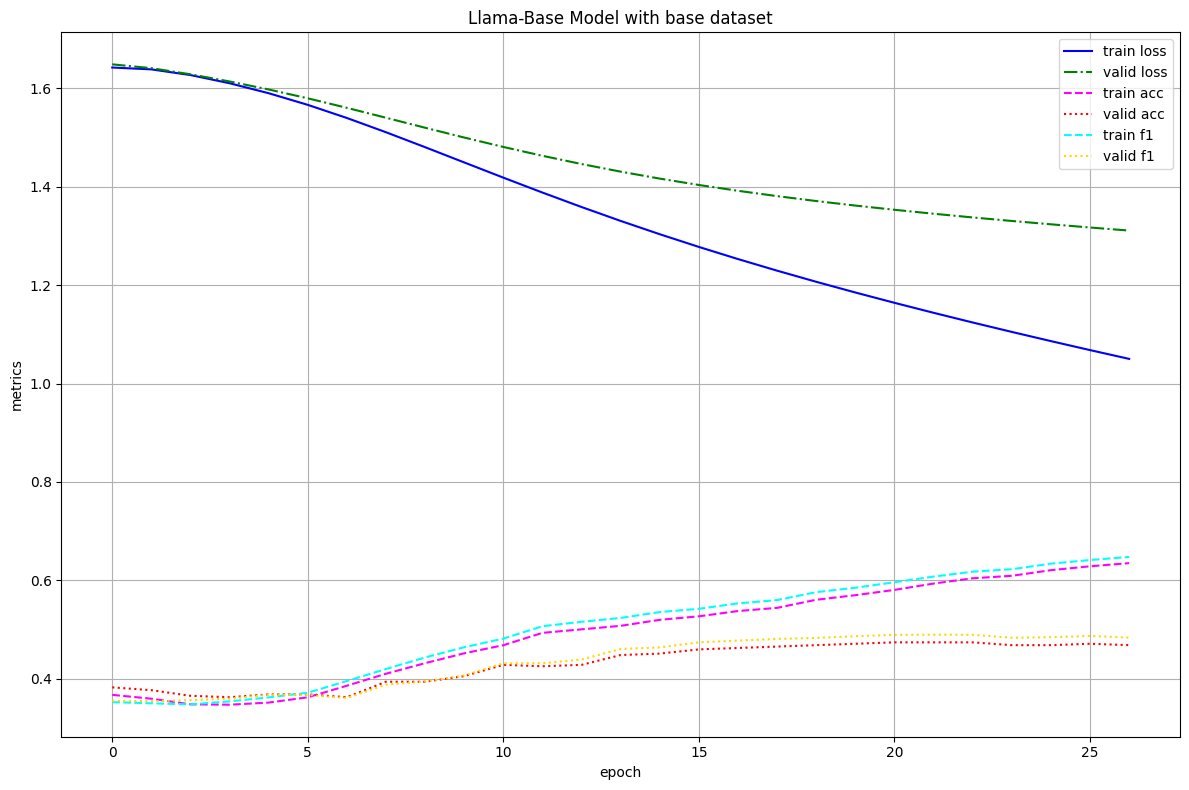

In [9]:
from utils import plot_result_curves

plot_result_curves(net, 'Llama-Base Model with base dataset');

# Evaluation

Similar to BERT, we experiment the use of the Llama model on this classification task. Because of limited compute resources, we use TinlyLlama 1.1B in place of Llama, which is an optimized version of the Llama model. The TinyLLama is compact with only 1.1 billion parameters, which allows us more flexibility with implementation on our own laptops/desktops. Since Llama 2 and TinyLLama share the same tokenizer and architecture, we can also easily switch this out to using the Llama 2 model in this experiment.

For our implementation, we use the base TinyLlama-1.1B-Chat-v1 model, and add an extra classification layer for determining the labels to try to save on compute for an initial experiment on using the latest LLM models for classification.

In [7]:
y_pred = net.predict(test.embed_all())
y_prob = net.predict_proba(test.embed_all())

In [8]:
from utils import print_evaluation_report

print_evaluation_report(y_pred, test, classes, 'Llama-Base Base Dataset')

Llama-Base Base Dataset Accuracy: 51.72%
Llama-Base Base Dataset Weighted F1-score: 0.5375

Classification Report:
               precision    recall  f1-score   support

      center     0.2727    0.3659    0.3125        41
   lean left     0.3651    0.3770    0.3710        61
  lean right     0.3214    0.4865    0.3871        37
        left     0.8235    0.5676    0.6720       222
       right     0.4000    0.5789    0.4731        76

    accuracy                         0.5172       437
   macro avg     0.4366    0.4752    0.4431       437
weighted avg     0.5917    0.5172    0.5375       437



# Classification report summary

In our findings, the model resulted in a relatively mediocre weighted f1 score at 0.5375 and decent accuracy at 51.72% at epoch 22, and thereafter performance started to drop. While this is better than LSTM but worst than BERT & FFNN TD-IDF, our validation loss was still trending downwards which does suggest we can fine tune the model further to achieve a higher performance. in our task.

Again, our parameters are very similar to our implementation of BERT, with the main exception of batch size, which we had to reduce due to compute reasons.

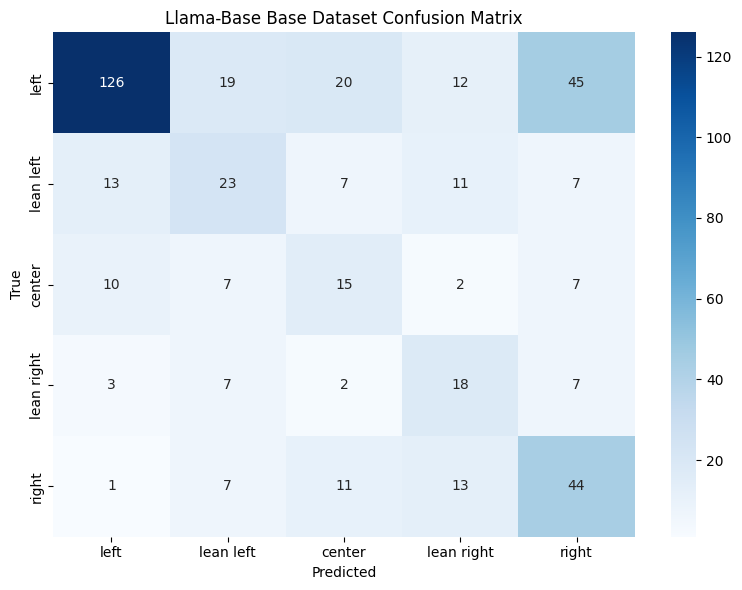

In [10]:
# Define correct label order
from utils import plot_confusion_matrix

plot_confusion_matrix(y_pred, test, classes, 'Llama-Base Base Dataset');

The TinyLlama model shows very similar results in the confusion matrix as our previous models. The biggest difference was that previous models had issues with determining the minority label, while TinyLlama did not have as much of an issue.

This was another reason we decided to further optimize this model despite the higher computation cost.

In [11]:
from utils import show_one_vs_rest_confusion_matrices

print('Confusion matrics for Llama-Base Base Dataset')
show_one_vs_rest_confusion_matrices(net, y_pred, test, classes)

Confusion matrics for Llama-Base Base Dataset

One-vs-Rest Confusion Matrix for class 'center':
[[356  40]
 [ 26  15]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[336  40]
 [ 38  23]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[362  38]
 [ 19  18]]

One-vs-Rest Confusion Matrix for class 'left':
[[188  27]
 [ 96 126]]

One-vs-Rest Confusion Matrix for class 'right':
[[295  66]
 [ 32  44]]


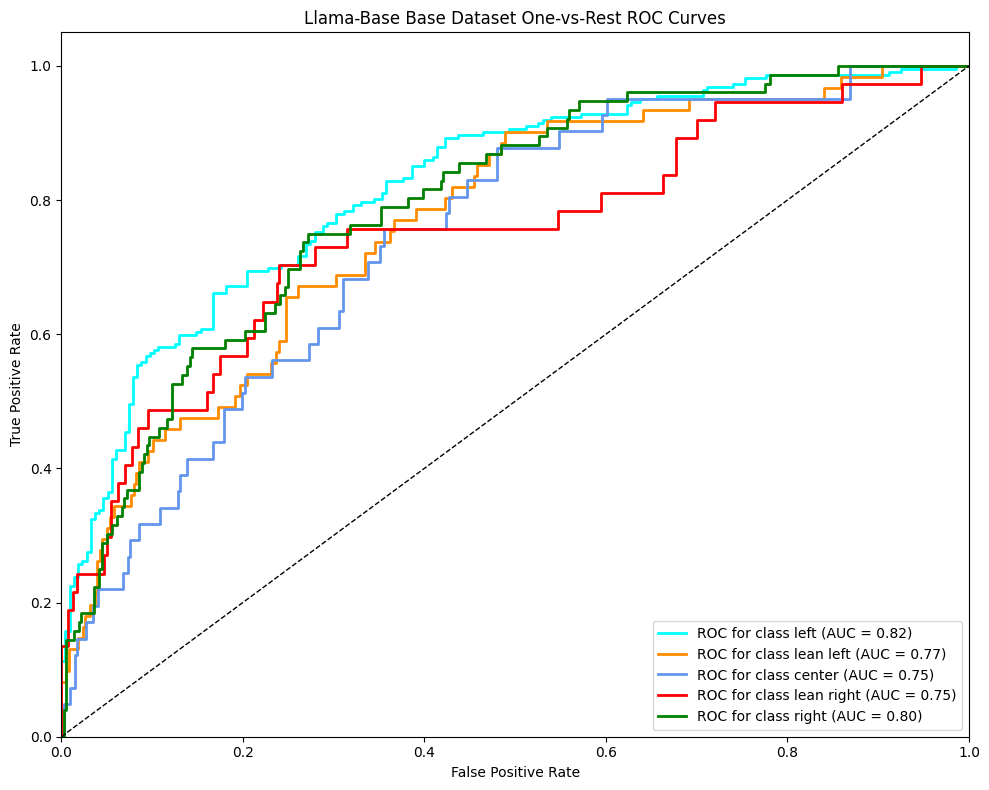

In [12]:
from utils import plot_roc


plot_roc(y_prob, net, test, classes, 'Llama-Base Base Dataset');

### Performance Metrics Evaluation Summary

| Model            | Accuracy | Weighted F1 |
|------------------|----------|-------------|
| Decision Tree    | 59.27    | 60.29       |
| FFNN (TD-IDF)    | 69.79    | 68.85       |
| FFNN (GloVe)     | 32.27    | 33.72       |
| LSTM             | 37.76    | 41.46       |
| BERT             | 60.41    | 61.04       |
| TinyLlama        | 51.72    | 53.75       |

### Final Remarks

Overall, TinyLlama showed some promising results in classification even with just a simple classification layer added to the base model. Given the availability of LoRA for fine tuning the model, this result prompted us to test the variation as well. 

The main limitation we face is the amount of compute needed for this model is significantly more than those we tested previously. This presents some challenges, one of which we mentioned was the reduction in our batch size. Another would be the amount of time needed to run this model, which is expected to increase when we augment our dataset with our scrapped data.